### Function to find kmers in sequence

In [4]:
def sequence_complexity(seq: str, k: int = 7) -> float:
    #seq --> sequence
    #k --> size of window ("word size") 
    
    seq = seq.upper()
    length = len(seq)
    complexity = 1.0

    for kmer_size in range(1, k + 1): # for every k-mer size inside window
        if length < kmer_size:
            continue # Can't form any k-mers of this size
        kmers = set()
        for i in range(length - kmer_size + 1):
            kmer = seq[i:i + kmer_size]
            kmers.add(kmer)

        observed = len(kmers)
        possible_kmers = min(4 ** kmer_size, length - kmer_size + 1)

        if possible_kmers == 0:
            continue # Skip division by zero if any
        complexity *= observed / possible_kmers

    return complexity

#### Retrieve the whole Chr1 from hg38 genome

In [5]:
# Creating "data_assignment/" directory
import os

path = "./data_assignment"
# Check if path exists
if not os.path.exists(path):
    # Create the directory
    os.makedirs(path)
    print(path, "directory created")
else:
    print(path, "directory exists")

./data_assignment directory created


In [6]:
# Check if human Chr1 hg38 file exists
fasta_path = './data_assignment/chr1.fa.gz'
if not os.path.exists(fasta_path):
    print("File does not exist. Downloading fasta file.")
    os.system('wget -q -O ./data_assignment/chr1.fa.gz "https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr1.fa.gz"')
else:
    print("File already exists. Skipping download.")

File does not exist. Downloading fasta file.


In [7]:
!gunzip -k ./data_assignment/chr1.fa.gz

In [ ]:
# Load and clean FASTA
with open("chr1.fa", 'r') as file:
    raw = file.read().upper()
    dna_seq = ''.join(base for base in raw if base in {'A', 'T', 'C', 'G'})

### Run the code

In [ ]:
# Sliding window
window_size = 500
step = 100
complexity_scores = []
positions = []

for j in range(0, len(dna_seq) - window_size + 1, step):
    window = dna_seq[j:j + window_size]
    score = sequence_complexity(window)
    positions.append(j)
    complexity_scores.append(score)


### Plot the complexity

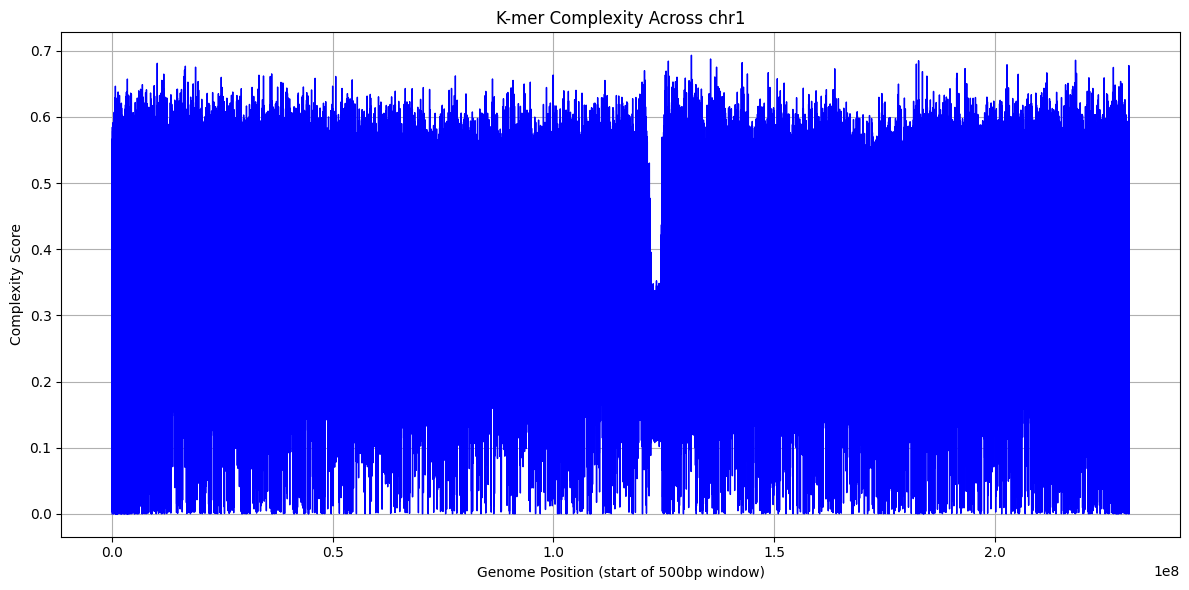

In [2]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(positions, complexity_scores, color='blue', linewidth=1)
plt.title("K-mer Complexity Across chr1")
plt.xlabel("Genome Position (start of 500bp window)")
plt.ylabel("Complexity Score")
plt.grid(True)
plt.tight_layout()
plt.show()